<a href="https://colab.research.google.com/github/epjf99-rgb/Entregas/blob/main/PrimerRedNeuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Dataset

Se genera un dataset que representa lo siguiente:
X es el porcentaje de dosis de un medicamento
y es la efectividad del medicamento, etiquetado como 0 (poco efectivo) y 1 (alta efectividad),


In [ ]:

import numpy as np
# Generar un rango de numeros, entre mas pequeño es DELTA mas datos
DELTA=0.001
X= np.arange(0.0,1.0,DELTA)
MAX = len(X)

# y se inicializa con ceros
y = np.zeros(MAX)

# y toma valor de 1 en el rango de X indicado
y[(X >= 0.33) & (X <= 0.66)] = 1
#numero de puntos
MAX

1000

Graficar el dataset, con muchos datos puede ser muy lento!!

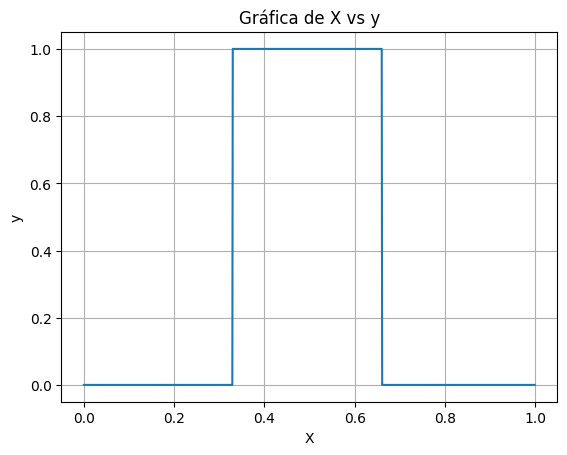

In [ ]:
# prompt: grafica X vs y usando matplotlig

import tensorflow as tf
import matplotlib.pyplot as plt



plt.plot(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Gráfica de X vs y")
plt.grid(True)
plt.show()

In [ ]:
X.shape

(1000,)

# Entrenar Multiperceptron

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

MultiPerceptron, el nodo de capa de salida es una regresión logística, por eso la función de activación es Sigmoid

In [ ]:
modelo=Sequential([
    Dense(2, input_shape=(1,), activation='relu'), # capa intermedia con 16 nodos
   # Dense(8, activation='relu'),                   # capa intermedia con 8 nodos
   # Dense(4, activation='relu'),                   # capa intermedia con 4 nodos
   # Dense(2, activation='relu'),                   # capa intermedia con 2 nodos
     Dense(1, activation='sigmoid')                #capa de salida con un nodo
  ]
)

Compilar el modelo es convertir a una estructura de Tensores y así mismo asignarle el optimizador y la función de pérdida (binary_crossentropy)
Se mide el entranamiento con respecto al accuracy

In [ ]:
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=30.5),
               loss='binary_crossentropy', metrics=['accuracy'])

fit es aplicar el algoritmo de backpropagation

In [ ]:
modelo.fit(X, y, epochs=150)

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6269 - loss: 112.2134 
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5812 - loss: 2.0498 
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6082 - loss: 1.3327 
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5173 - loss: 1.1450 
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5924 - loss: 0.8542 
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5672 - loss: 0.9938 
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6192 - loss: 1.5512
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5043 - loss: 0.9761
Epoch 9/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5748 - loss: 0.9059
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5531 - loss: 1.0121
Epoch 11/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5588 - loss: 0.8536 
Epoch 12/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

Algoritmo de Backpropagation para un Multiperceptron
El algoritmo de Backpropagation (retropropagación del error) es un método fundamental para entrenar redes neuronales artificiales, especialmente Multiperceptrones.   
Su propósito principal es ajustar los pesos y sesgos de la red para reducir la diferencia entre las salidas que produce la red y las salidas deseadas (las "etiquetas" o valores reales) para un conjunto de datos de entrenamiento.
Este proceso se repite hasta que el error se minimiza.



Algoritmo de Backpropagation
Para cada patrón de entrenamiento (entrada x, salida esperada y):

    Fase 1: Pasada hacia adelante (Forward Pass)
    1. Inicializar la capa de entrada con x: a^(0) = x
    2. Para cada capa l desde 1 hasta L:
        Para cada neurona j en la capa l:
            a. Calcular la entrada neta: z^(l)_j = Suma(w^(l)_ij * a^(l-1)_i) + b^(l)_j  (sumando sobre i)
            b. Calcular la activación: a^(l)_j = f(z^(l)_j)
    3. La salida de la red es la activación de la última capa: a^(L)
    4. Calcular el error utilizando la función de costo C(a^(L), y)

    Fase 2: Pasada hacia atrás (Backward Pass)
    1. Calcular el error de la capa de salida (l=L).
       Si se usa el error cuadrático medio y sigmoide en la salida:
       delta^(L)_j = (a^(L)_j - y_j) * f'(z^(L)_j)

    2. Para cada capa l desde L-1 hasta 1 (propagando hacia atrás):
        Para cada neurona j en la capa l:
            a. Calcular el error delta^(l)_j propagando el error de la capa siguiente:
               delta^(l)_j = (Suma(w^(l+1)_jk * delta^(l+1)_k) ) * f'(z^(l)_j) (sumando sobre k)

    3. Actualización de Pesos y Sesgos
    Para cada capa l desde 1 hasta L:
        Para cada conexión entre la neurona i de la capa l-1 y la neurona j de la capa l:
            a. Actualizar el peso: w^(l)_ij = w^(l)_ij - eta * (delta^(l)_j * a^(l-1)_i)
            b. Actualizar el sesgo: b^(l)_j = b^(l)_j - eta * delta^(l)_j

Repetir para un número determinado de épocas (iteraciones sobre todo el conjunto de entrenamiento) o hasta que el error sea aceptable.


summary imprime la cantidad de parámetros por capa (no olvidar el Bias)

In [ ]:
modelo.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (96.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16 (68.00 B)